In [1]:
# Digital Marketing Conversion Analysis

# This project analyzes a synthetic digital marketing dataset to explore two business Ïquestions:

# 1. Can customer conversion be predicted using demographic, campaign, and engagement features?
# 2. Can customers be segmented into meaningful groups for more targeted marketing strategies?

# The analysis combines logistic regression for conversion prediction and k-means clustering for customer segmentation. 
# Because the dataset is synthetic, results should be interpreted as illustrative rather than as evidence from a live business environment.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

In [3]:
## 1. Load and Inspect the Data

In [4]:
df = pd.read_csv("digital_marketing_campaign_dataset.csv")
print(df.shape)
df.head()

(8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [6]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [7]:
print("Missing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values by column:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

Duplicate rows: 0


In [8]:
categorical_review_cols = [
    "Gender",
    "CampaignChannel",
    "CampaignType",
    "AdvertisingPlatform",
    "AdvertisingTool"
]

for col in categorical_review_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Female    4839
Male      3161
Name: count, dtype: int64

CampaignChannel
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

CampaignType
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

AdvertisingPlatform
AdvertisingPlatform
IsConfid    8000
Name: count, dtype: int64

AdvertisingTool
AdvertisingTool
ToolConfid    8000
Name: count, dtype: int64


In [9]:
# Remove nonpredictive identifier and constant value columns
df = df.drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"])
df.head()

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [10]:
## 2. Explore the Target Variable and Prepare Features

In [11]:
print("Conversion counts:")
print(df["Conversion"].value_counts())

print("\nConversion proportions:")
print(df["Conversion"].value_counts(normalize=True))

Conversion counts:
Conversion
1    7012
0     988
Name: count, dtype: int64

Conversion proportions:
Conversion
1    0.8765
0    0.1235
Name: proportion, dtype: float64


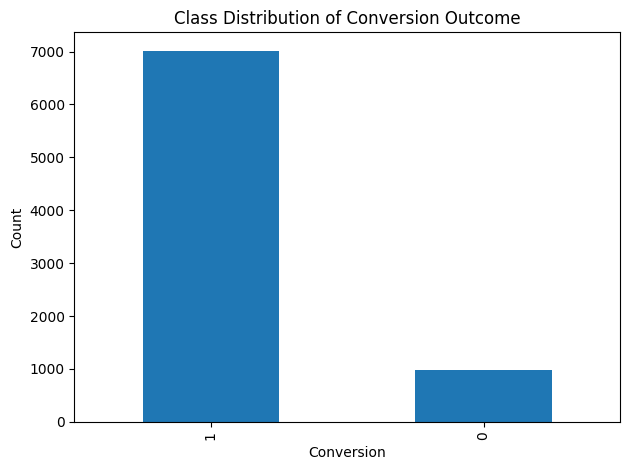

In [12]:
df["Conversion"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Conversion Outcome")
plt.xlabel("Conversion")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
# The target variable is imbalanced, with converted customers (1) appearing much more frequently than nonconverted customers (0).
# Because of this, model evaluation should consider precision, recall, F1 score, and the confusion matrix rather than relying on accuracy alone.

In [14]:
numeric_corr = df.corr(numeric_only=True)["Conversion"].sort_values(ascending=False)
print(numeric_corr)

Conversion           1.000000
TimeOnSite           0.129609
EmailClicks          0.129521
EmailOpens           0.124884
AdSpend              0.124672
ClickThroughRate     0.120012
PreviousPurchases    0.111781
PagesPerVisit        0.102840
LoyaltyPoints        0.095004
ConversionRate       0.093185
WebsiteVisits        0.079339
Income               0.013974
Age                  0.001606
SocialShares        -0.011449
Name: Conversion, dtype: float64


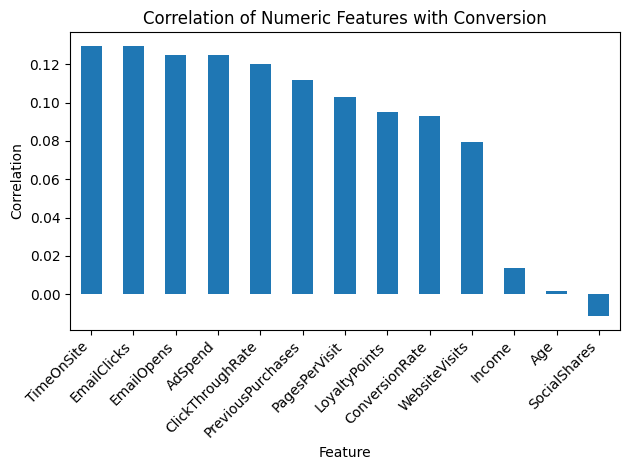

In [15]:
# Visualize correlations between numeric features and the conversion target
numeric_corr.drop("Conversion").plot(kind="bar")
plt.title("Correlation of Numeric Features with Conversion")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# Separate predictors and target variable
X = df.drop("Conversion", axis=1)
y = df["Conversion"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (8000, 16)
Target vector shape: (8000,)


In [17]:
# Define categorical and numeric feature groups
categorical_cols = ["Gender", "CampaignChannel", "CampaignType"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'CampaignChannel', 'CampaignType']
Numeric columns: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


In [18]:
# One-hot encode categorical variables for modeling
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Encoded feature matrix shape:", X_encoded.shape)
X_encoded.head()

Encoded feature matrix shape: (8000, 21)


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,PreviousPurchases,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,4,688,False,False,False,False,True,False,False,False
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,2,3459,True,False,False,False,False,False,False,True
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,8,2337,False,True,False,False,False,False,False,False
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,0,2463,False,True,False,False,False,False,True,False
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,8,4345,False,True,False,False,False,False,True,False


In [19]:
## 3. Train and Evaluate the Baseline Logistic Regression Model

In [20]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6400, 21)
X_test shape: (1600, 21)
y_train shape: (6400,)
y_test shape: (1600,)


In [21]:
# Scale features using statistics learned from the training set
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (6400, 21)
Scaled X_test shape: (1600, 21)


In [22]:
# Train a baseline logistic regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
# Generate predictions on the test set
y_pred = log_model.predict(X_test_scaled)

In [24]:
# Evaluate classification performance
print("Baseline Logistic Regression Performance")
print("----------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Baseline Logistic Regression Performance
----------------------------------------
Accuracy: 0.8912
Precision: 0.8946
Recall: 0.9929
F1 Score: 0.9412


In [25]:
# Confusion matrix to examine prediction errors across classes
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print("----------------")
print(cm)

Confusion Matrix
----------------
[[  34  164]
 [  10 1392]]


In [26]:
# Detailed classification report
print("Classification Report")
print("---------------------")
print(classification_report(y_test, y_pred))

Classification Report
---------------------
              precision    recall  f1-score   support

           0       0.77      0.17      0.28       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600



In [27]:
## 4. Compare an Imbalance-Aware Model

In [28]:
# Train a class-weighted logistic regression model to address target imbalance
log_model_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
log_model_balanced.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_balanced = log_model_balanced.predict(X_test_scaled)

In [29]:
print("Original Logistic Regression")
print("----------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nClass Weighted Logistic Regression")
print("----------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_balanced), 4))
print("Precision:", round(precision_score(y_test, y_pred_balanced), 4))
print("Recall:", round(recall_score(y_test, y_pred_balanced), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_balanced), 4))

Original Logistic Regression
----------------------------
Accuracy: 0.8912
Precision: 0.8946
Recall: 0.9929
F1 Score: 0.9412

Class Weighted Logistic Regression
----------------------------------
Accuracy: 0.7531
Precision: 0.9524
Recall: 0.7561
F1 Score: 0.8429


In [30]:
print("Class Weighted Logistic Regression Diagnostics")
print("---------------------------------------------")
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report")
print(classification_report(y_test, y_pred_balanced))

Class Weighted Logistic Regression Diagnostics
---------------------------------------------
Confusion Matrix
[[ 145   53]
 [ 342 1060]]

Classification Report
              precision    recall  f1-score   support

           0       0.30      0.73      0.42       198
           1       0.95      0.76      0.84      1402

    accuracy                           0.75      1600
   macro avg       0.63      0.74      0.63      1600
weighted avg       0.87      0.75      0.79      1600



In [31]:
# The baseline logistic regression model performed strongly overall, especially in identifying likely converters. 
# However, because the target variable was highly imbalanced, the model was much less effective at identifying nonconverted customers. 
# A class weighted logistic regression model was tested to improve minority class detection. 
# Although it substantially improved recall for non converted customers, it reduced overall accuracy and weakened performance on converted customers. 
# For this project, the baseline model was retained as the primary model because it better supported the business objective of identifying likely converters.

In [32]:
## 5. Checkpoint: Stricter Logistic Regression Model

In [33]:
# Create a stricter feature set by removing target-adjacent variables
X_strict = X.drop(columns=["ConversionRate", "ClickThroughRate"])

print("Original feature shape:", X.shape)
print("Stricter feature shape:", X_strict.shape)

Original feature shape: (8000, 16)
Stricter feature shape: (8000, 14)


In [34]:
# One-hot encode categorical variables for the stricter model
X_strict_encoded = pd.get_dummies(X_strict, columns=categorical_cols, drop_first=True)

print("Encoded stricter feature matrix shape:", X_strict_encoded.shape)
X_strict_encoded.head()

Encoded stricter feature matrix shape: (8000, 19)


,Age,Income,AdSpend,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,136912,6497.870068,0,2.399017,7.396803,19,6,9,4,688,False,False,False,False,True,False,False,False
1,69,41760,3898.668606,42,2.917138,5.352549,5,2,7,2,3459,True,False,False,False,False,False,False,True
2,46,88456,1546.429596,2,8.223619,13.794901,0,11,2,8,2337,False,True,False,False,False,False,False,False
3,32,44085,539.525936,47,4.540939,14.688363,89,2,2,0,2463,False,True,False,False,False,False,True,False
4,60,83964,1678.043573,0,2.046847,13.993370,6,6,6,8,4345,False,True,False,False,False,False,True,False


In [35]:
# Split the stricter feature set into training and test sets
X_train_strict, X_test_strict, y_train_strict, y_test_strict = train_test_split(
    X_strict_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features using statistics learned from the training set
strict_scaler = StandardScaler()

X_train_strict_scaled = pd.DataFrame(
    strict_scaler.fit_transform(X_train_strict),
    columns=X_train_strict.columns,
    index=X_train_strict.index
)

X_test_strict_scaled = pd.DataFrame(
    strict_scaler.transform(X_test_strict),
    columns=X_test_strict.columns,
    index=X_test_strict.index
)

In [36]:
# Train a stricter logistic regression model without target-adjacent variables
log_model_strict = LogisticRegression(max_iter=1000, random_state=42)
log_model_strict.fit(X_train_strict_scaled, y_train_strict)

# Generate predictions
y_pred_strict = log_model_strict.predict(X_test_strict_scaled)

In [37]:
print("Stricter Logistic Regression Performance")
print("----------------------------------------")
print("Accuracy:", round(accuracy_score(y_test_strict, y_pred_strict), 4))
print("Precision:", round(precision_score(y_test_strict, y_pred_strict), 4))
print("Recall:", round(recall_score(y_test_strict, y_pred_strict), 4))
print("F1 Score:", round(f1_score(y_test_strict, y_pred_strict), 4))

print("\nConfusion Matrix")
print("----------------")
print(confusion_matrix(y_test_strict, y_pred_strict))

print("\nClassification Report")
print("---------------------")
print(classification_report(y_test_strict, y_pred_strict))

Stricter Logistic Regression Performance
----------------------------------------
Accuracy: 0.8819
Precision: 0.8866
Recall: 0.9922
F1 Score: 0.9364

Confusion Matrix
----------------
[[  20  178]
 [  11 1391]]

Classification Report
---------------------
              precision    recall  f1-score   support

           0       0.65      0.10      0.17       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.88      1600
   macro avg       0.77      0.55      0.56      1600
weighted avg       0.86      0.88      0.84      1600



In [38]:
print("Original Logistic Regression")
print("----------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nStricter Logistic Regression")
print("----------------------------")
print("Accuracy:", round(accuracy_score(y_test_strict, y_pred_strict), 4))
print("Precision:", round(precision_score(y_test_strict, y_pred_strict), 4))
print("Recall:", round(recall_score(y_test_strict, y_pred_strict), 4))
print("F1 Score:", round(f1_score(y_test_strict, y_pred_strict), 4))

Original Logistic Regression
----------------------------
Accuracy: 0.8912
Precision: 0.8946
Recall: 0.9929
F1 Score: 0.9412

Stricter Logistic Regression
----------------------------
Accuracy: 0.8819
Precision: 0.8866
Recall: 0.9922
F1 Score: 0.9364


In [39]:
# Examine feature coefficients from the stricter logistic regression model
coef_df_strict = pd.DataFrame({
    "Feature": X_train_strict_scaled.columns,
    "Coefficient": log_model_strict.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df_strict

,Feature,Coefficient
5,TimeOnSite,0.486146
8,EmailClicks,0.462567
2,AdSpend,0.437724
9,PreviousPurchases,0.418458
7,EmailOpens,0.416020
17,CampaignType_Conversion,0.395557
4,PagesPerVisit,0.379758
10,LoyaltyPoints,0.374048
3,WebsiteVisits,0.260642
12,CampaignChannel_PPC,0.098578


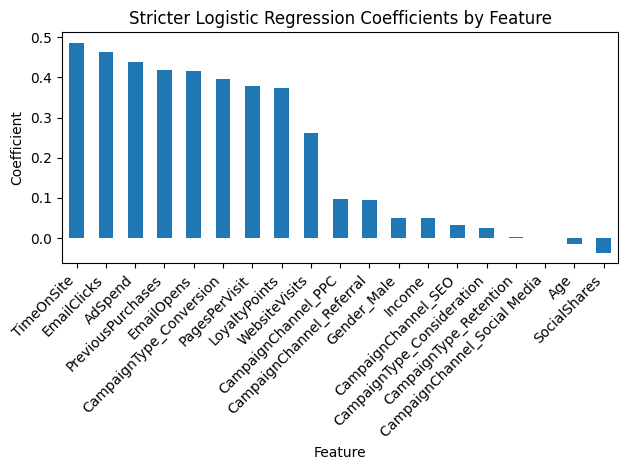

In [40]:
# Visualize coefficient direction and magnitude for the stricter model
coef_df_strict.plot(x="Feature", y="Coefficient", kind="bar", legend=False)
plt.title("Stricter Logistic Regression Coefficients by Feature")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [41]:
# To test whether the model’s performance depended too heavily on variables closely related to the target outcome, a stricter logistic regression model was evaluated without ConversionRate and ClickThroughRate. 
# Performance declined only slightly, suggesting that the model retained meaningful predictive signal even after removing those target adjacent features. 
# In the stricter model, variables such as time on site, email clicks, ad spend, previous purchases, email opens, pages per visit, and loyalty points remained positively associated with conversion. 
# These patterns suggest that customer engagement and prior purchasing behavior were important signals in predicting campaign response.

In [42]:
## 6. Segment Customers with K-Means Clustering

In [43]:
# Select numeric features for customer segmentation
cluster_features = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "ConversionRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]

X_cluster = df[cluster_features]
X_cluster.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345


In [44]:
# Scale clustering features so variables are on comparable ranges
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Scaled clustering matrix shape:", X_cluster_scaled.shape)

Scaled clustering matrix shape: (8000, 13)


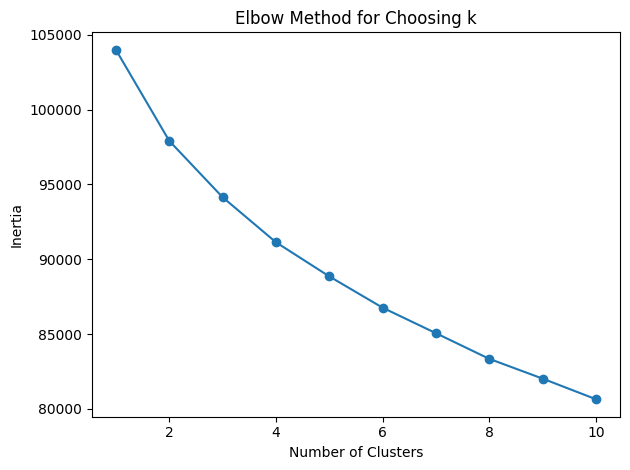

In [45]:
# Use the elbow method to examine candidate values of k
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [46]:
# Compare silhouette scores to help select the number of clusters
# and evaluate how well separated the resulting segments are
silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, cluster_labels)
    silhouette_scores.append((k, score))

for k, score in silhouette_scores:
    print(f"k = {k}, silhouette score = {score:.4f}")

silhouette_df = pd.DataFrame(silhouette_scores, columns=["k", "silhouette_score"])
silhouette_df

k = 2, silhouette score = 0.0582
k = 3, silhouette score = 0.0500
k = 4, silhouette score = 0.0522
k = 5, silhouette score = 0.0493
k = 6, silhouette score = 0.0498


,k,silhouette_score
0,2,0.058166
1,3,0.049998
2,4,0.052197
3,5,0.049283
4,6,0.049838


In [47]:
# Among the values tested, k=2 produced the highest silhouette score. 
# However, the silhouette values were low overall, which suggests that customer segments in this dataset are only modestly separated. 
# As a result, the clustering analysis is best interpreted as exploratory segmentation rather than evidence of sharply distinct customer groups.

In [48]:
# Fit the final K-means model using k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

df[["Conversion", "Cluster"]].head()

,Conversion,Cluster
0,1,0
1,1,1
2,1,0
3,1,0
4,1,1


In [49]:
print("Cluster sizes:")
print(df["Cluster"].value_counts())

Cluster sizes:
Cluster
0    4045
1    3955
Name: count, dtype: int64


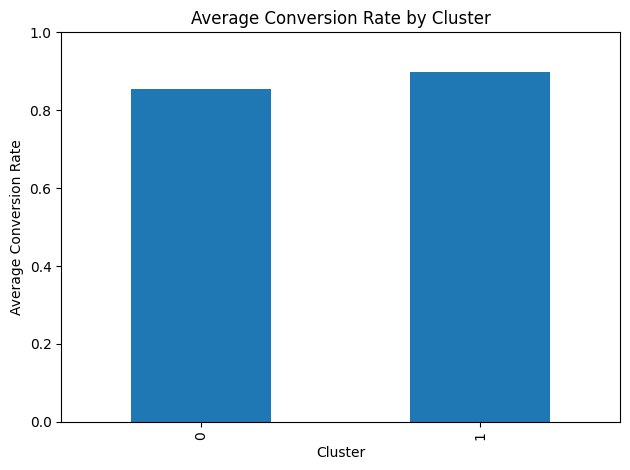

In [50]:
# Visualize conversion rate by cluster
df.groupby("Cluster")["Conversion"].mean().plot(kind="bar")
plt.title("Average Conversion Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Conversion Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

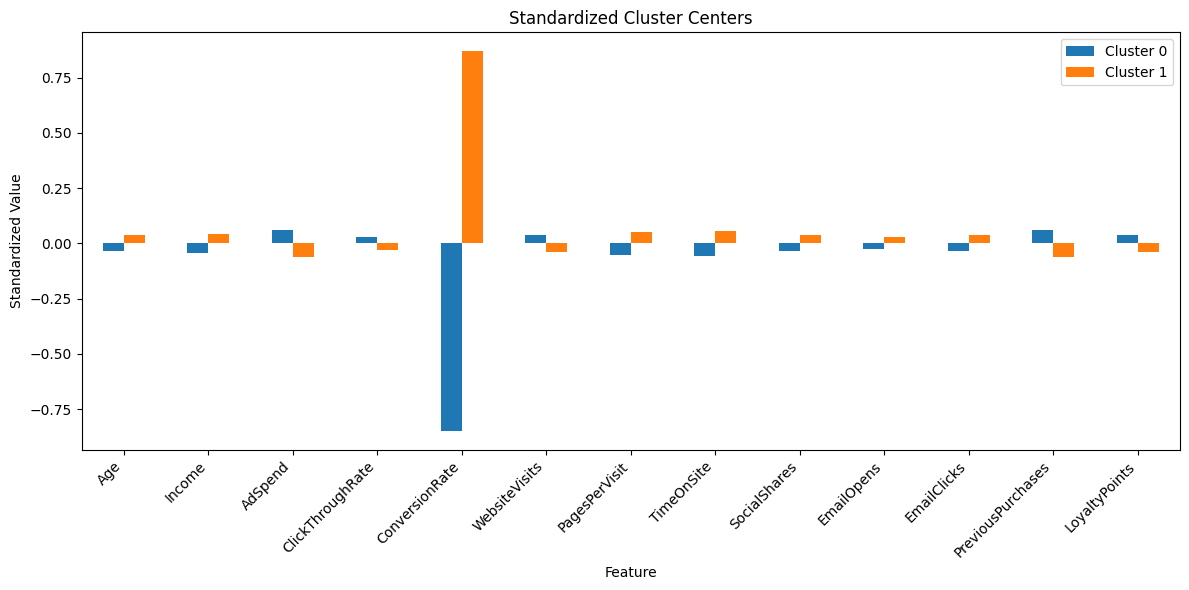

In [51]:
# Plot standardized cluster centers
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features,
    index=["Cluster 0", "Cluster 1"]
)

cluster_centers.T.plot(kind="bar", figsize=(12, 6))
plt.title("Standardized Cluster Centers")
plt.xlabel("Feature")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [52]:
# Create a rounded cluster summary table for interpretation
cluster_report = df.groupby("Cluster")[cluster_features + ["Conversion"]].mean().round(3)
cluster_report

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
Cluster,,,,,,,,,,,,,,
0,43.130,83185.493,5164.250,0.157,0.058,25.282,5.416,7.488,48.829,9.322,4.373,4.660,2541.510,0.856
1,44.132,86176.550,4833.924,0.152,0.152,24.209,5.686,7.973,50.792,9.635,4.564,4.307,2437.861,0.898


In [53]:
# K-means clustering identified two similarly sized customer segments, with one cluster showing somewhat higher conversion and stronger engagement related metrics. 
# Among the values tested, k=2 produced the highest silhouette score, but the silhouette values were low overall. 
# This suggests that the segments are only modestly separated, so the clustering results should be treated as exploratory rather than as definitive customer personas.

In [54]:
## 7. Final Conclusions

In [55]:
# This project used a synthetic digital marketing dataset to explore conversion prediction and customer segmentation. 
# The baseline logistic regression model performed strongly overall in predicting likely converters, although it was less effective at identifying nonconverted customers because of the class imbalance in the target variable. 
# A class weighted version improved recall for nonconverted customers, but at a substantial cost to overall performance. 
# A stricter model excluding target adjacent variables produced only a small decline in performance, suggesting that the predictive signal was not driven only by those fields.
# The clustering analysis identified two broad customer segments with modest differences in engagement and conversion. 
# Because silhouette scores were low overall, these segments should be interpreted as exploratory groupings rather than sharply distinct customer personas.
# The project demonstrates an end to end analytics workflow that includes data inspection, feature preparation, classification modeling, robustness checks, and exploratory segmentation in a marketing context.

In [56]:
print("Baseline Logistic Regression Performance")
print("----------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nCluster Sizes")
print("-------------")
print(df["Cluster"].value_counts())

print("\nAverage Conversion Rate by Cluster")
print("----------------------------------")
print(df.groupby("Cluster")["Conversion"].mean().round(4))

Baseline Logistic Regression Performance
----------------------------------------
Accuracy: 0.8912
Precision: 0.8946
Recall: 0.9929
F1 Score: 0.9412

Cluster Sizes
-------------
Cluster
0    4045
1    3955
Name: count, dtype: int64

Average Conversion Rate by Cluster
----------------------------------
Cluster
0    0.8556
1    0.8979
Name: Conversion, dtype: float64
